# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

Autorzy:
Grzegorz Cyba, 274859
Jan Galewicz 272587

---

## 1. Wstęp



wybrany temat

co chcemy zrobić aka założenia

krótki opis fouriera

zastosowania - do czego się używa

wszystko krótko bo dalej będzie rozwinięte

---

## 2. Generator danych

W celu przeprowadzenia kompleksowej weryfikacji efektywności algorytmu kompresji widmowej opartego na transformacie Fouriera, niezbędne było przygotowanie zróżnicowanego materiału badawczego. Zaimplementowane środowisko pozwala na generowanie trzech klas sygnałów o odmiennych właściwościach w domenie czasu i częstotliwości. Pozwala to na rygorystyczne przetestowanie mechanizmu progowania współczynników pod kątem dokładności rekonstrukcji, zachowania energii oraz zmian entropii sygnału.

### 2.1. Budowa zbioru danych i symulacja zaszumienia pomiarowego

Masowa synteza oraz agregacja struktur sygnałowych realizowana jest przez klasę zarządczą *DatasetCreator*. Narzędzie to automatyzuje proces budowy zbalansowanego datasetu testowego w dyskretnej dziedzinie czasu dla następujących parametrów:
- $t_0 = 0\text{ s}$ — czas początkowy przebiegu,
- $t_{end} = 500\text{ s}$ — czas końcowy przebiegu,
- $dt = 0.1\text{ s}$ — krok czasowy (co daje wektor o długości 5000 próbek),
- $u(t) \in [1, 10]$ — zakres dopuszczalnych wartości (amplitud).

**Powtarzalność i determinizm widma:**

W celu zapewnienia pełnej replikowalności eksperymentów, klasa wykorzystuje obiektowy generator liczb pseudolosowych *np.random.default_rng(seed)*. Przekazywanie tej samej instancji stanu losowego (*rng*) do klas sygnałowych gwarantuje, że przy identycznym ziarnie (seed) wygenerowane trajektorie czasowe oraz ich struktura spektralna (układ harmonicznych w widmie) będą identyczne przy każdym uruchomieniu.

**Separacja danych czystych i zaszumionych:**

Architektura generatora wymusza ścisły podział na fazę syntezy oraz fazę eksperymentu szumowego:
1. Generowanie bazy (*create_dataset*): Tworzy i zapisuje w instancji (*self.dataset*) wyłącznie idealnie czyste, referencyjne trajektorie dla każdej z trzech klas sygnałów.
2. Generowanie zakłóceń (*create_noisy_dataset_copy*): Tworzy głęboką kopię (*deepcopy*) czystego zbioru bazowego i nakłada na nią szum Gaussowski o intensywności zdefiniowanej przez parametr *noise_level* ($\sigma$). Pozwala to na rygorystyczne badanie wpływu kompresji Fouriera na ten sam sygnał przy różnych poziomach zakłóceń, bez niszczenia danych źródłowych.

Proces zaszumiania kopii realizowany jest zgodnie z zależnością:

$$y_{noisy} = y_{clean} + N(0, \sigma)$$

Aby wartości sygnału po zaszumieniu nie przekroczyły barier fizycznych, końcowy wektor poddawany jest operacji saturacji do przedziału $[u_{min}, u_{max}]$ za pomocą funkcji *np.clip*. Wygenerowane pakiety danych (wektory $t$ oraz $y$) są ostatecznie kapsułkowane w ustrukturyzowanych obiektach klasy *SignalData* i mapowane w zbiorczym słowniku pod kluczami *aprbs*, *multisine* oraz *noise*.

### 2.2 Klasy sygnałów

Każda z zaimplementowanych klas sygnału reprezentuje inny typ struktury spektralnej, co pozwala na ocenę uniwersalności projektowanego kodeka.


#### 2.2.1. Sygnał APRBS (Amplitude Pseudo-Random Binary Sequence)


Sygnał ten charakteryzuje się gwałtownymi, dyskretnymi zmianami amplitudy (skokami napięcia) utrzymywanymi przez losowy czas. Dla każdego pojedynczego przebiegu parametry czasowe są losowane stochastycznie z następujących zakresów:
- $h_{min} \in [50; 150]$ — zakres, z którego losowany jest minimalny czas trwania pojedynczego kroku,
- $h_{add} \in [100; 300]$ — przedział definiujący dodatkowy czas, który po zsumowaniu z $h_{min}$ określa maksymalny czas trwania kroku ($h_{max}$).

Znaczenie w analizie kompresji: Z punktu widzenia analizy Fouriera, ostre zbocza i nieskończony gradient zmian w dziedzinie czasu generują ciągłe, bardzo bogate spektrum częstotliwościowe o wolno wygasających harmonicznych. Jest to najtrudniejszy test dla algorytmu kompresji widmowej. Wycięcie wysokich częstotliwości (współczynników FFT) prowadzi do utraty ostrości krawędzi i generuje charakterystyczne oscylacje wokół punktów skoku po wykonaniu odwrotnej transformaty (tzw. efekt Gibbsa). Pozwala to zbadać, jak mocno ucinanie pasma zniekształca skokowe sygnały szybkozmienne.

Generowanie APRBS:   0%|          | 0/10 [00:00<?, ?it/s]

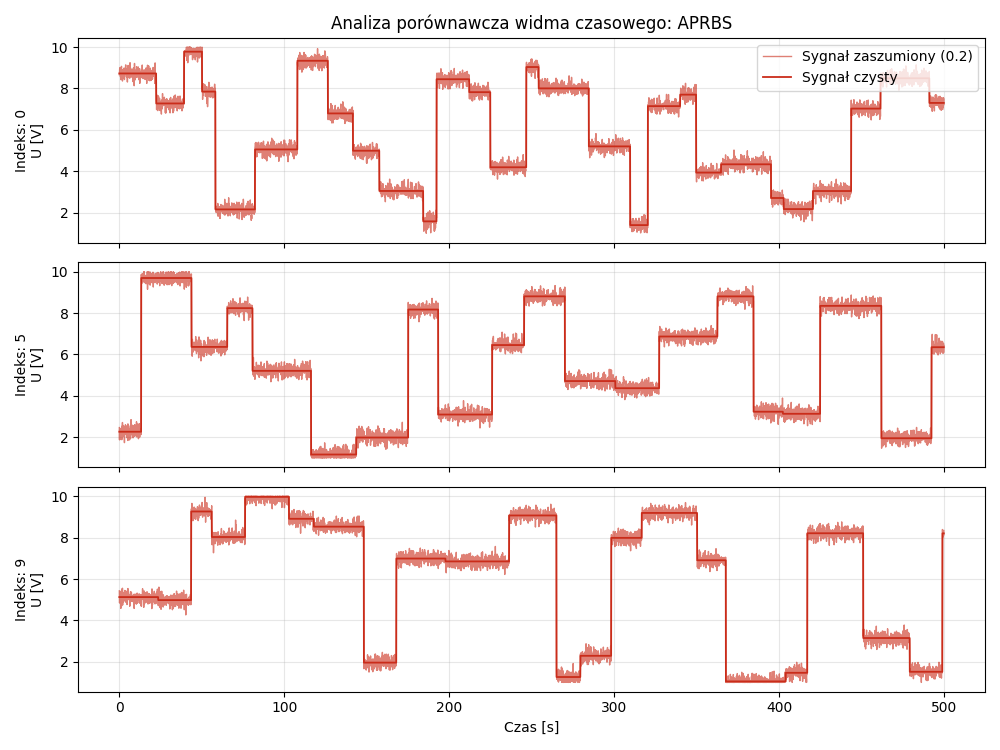

In [1]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=0, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9], signals_noisy=dataset_noisy['aprbs'], noise_level=creator.noise_level)


#### 2.2.2. Sygnał Multisine (Wieloczęstotliwościowy)

Sygnał ten stanowi deterministyczną sumę składowych harmonicznych (sinusoid) o losowych fazach i częstotliwościach. Dla każdego przebiegu parametry konfiguracyjne losowane są z przedziałów:
- $n_f \in [5; 15]$ — zakres, z którego losowana jest liczba składowych sinusoidalnych,
- $f_{max} \in [0.005; 0.02]\text{ Hz}$ — zakres, z którego losowana jest maksymalna dopuszczalna częstotliwość pojedynczej sinusoidy.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten charakteryzuje się ściśle dyskretnym spektrum prążkowym. Cała energia sygnału skupiona jest w dokładnie $n_f$ punktach widma, podczas gdy pozostała część pasma przyjmuje wartości zerowe. Dla kodeka fourierowskiego jest to sygnał idealny. Algorytm progowania powinien bezbłędnie wyizolować i zachować wyłącznie dominujące prążki częstotliwościowe, co pozwala na uzyskanie minimalnego błędu rekonstrukcji (MSE) i stabilnej entropii widmowej nawet przy bardzo niskim procencie zachowanych danych.

Generowanie MULTISINE:   0%|          | 0/10 [00:00<?, ?it/s]

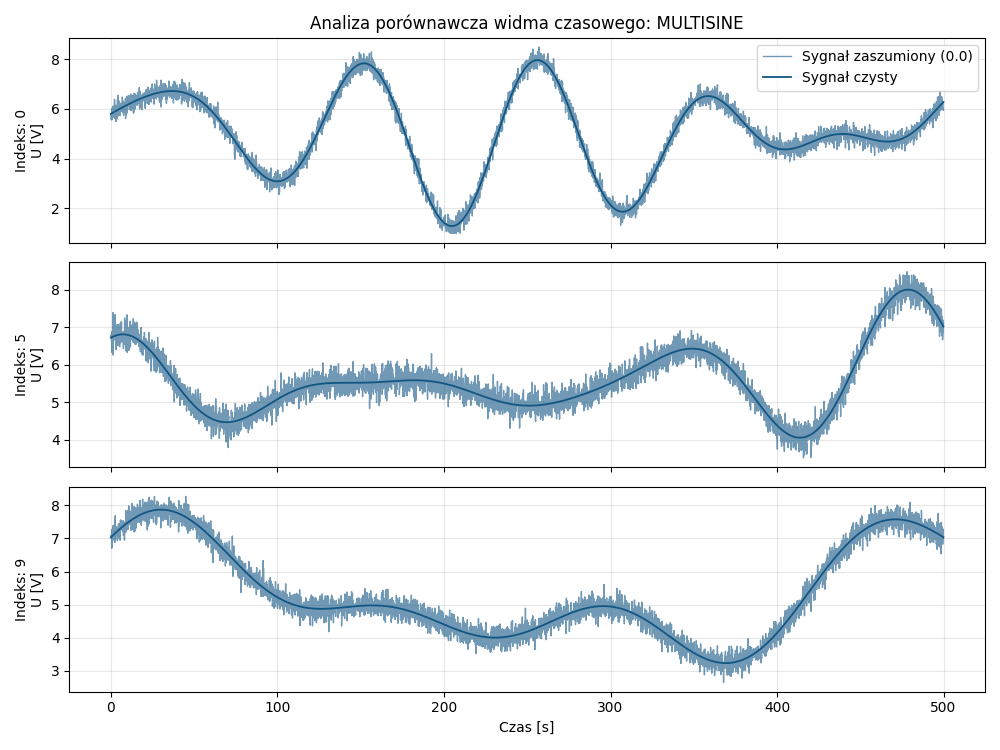

In [ ]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=10, n_noise=0)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9], signals_noisy=dataset_noisy['multisine'], noise_level=creator.noise_level)

#### 2.2.3. Przefiltrowany szum dolnoprzepustowy (Filtered Noise)

Sygnał reprezentujący przebieg chaotyczny o kontrolowanym paśmie. Powstaje poprzez generację stochastycznego szumu białego o rozkładzie normalnym, który następnie poddawany jest cyfrowej filtracji dolnoprzepustowej pierwszego rzędu. Częstotliwość odcięcia filtra jest parametrem losowym:
- $cutoff \in [0.001; 0.01]\text{ Hz}$ — zakres losowania częstotliwości odcięcia.

Znaczenie w analizie kompresji: W dziedzinie częstotliwości sygnał ten posiada gęste, ciągłe pasmo szumowe ograniczone od góry filtrem wygładzającym. Brak pojedynczych, dominujących częstotliwości sprawia, że energia jest rozproszona. Pozwala to na zbadanie, jak algorytm kompresji radzi sobie z sygnałami stochastycznymi, gdzie ucinanie współczynników przekłada się bezpośrednio na liniową utratę losowej energii tła, co stanowi kluczowy punkt weryfikacji zmian entropii widmowej oraz dokładności odwzorowania szumów procesowych.

Generowanie NOISE:   0%|          | 0/10 [00:00<?, ?it/s]

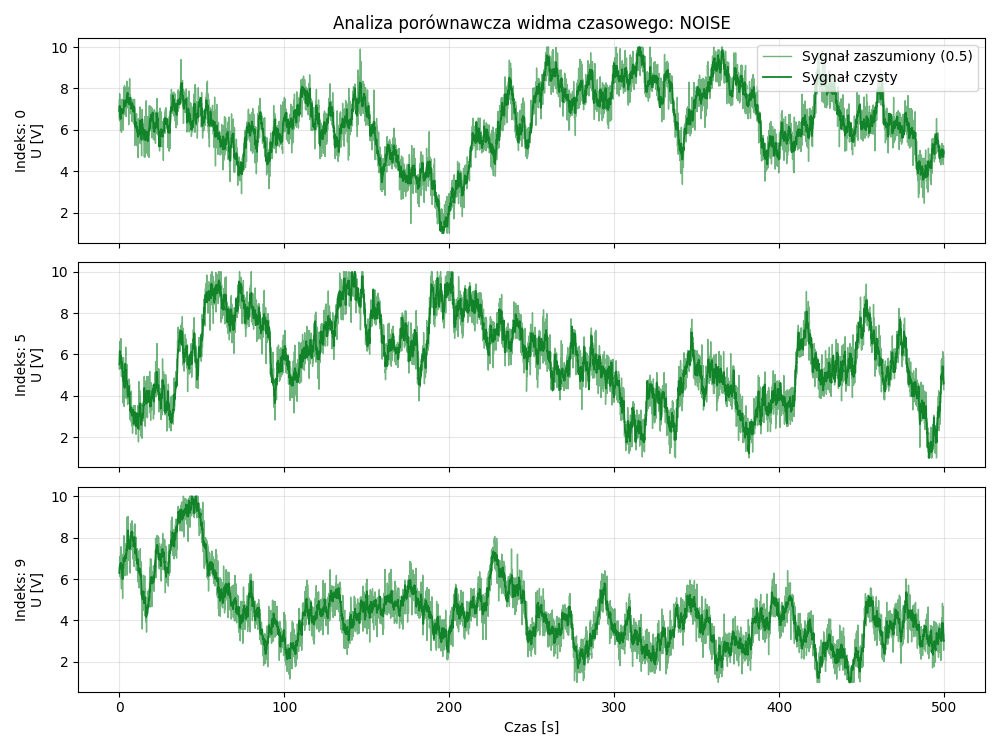

In [6]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.5, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=10)
dataset_noisy = creator.create_noisy_dataset_copy()

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9], signals_noisy=dataset_noisy['noise'], noise_level=creator.noise_level)

---

## 3. Fourier

podstawy teoretyczne (DFT)
- prosty
- odwrotny

opis kodu w markdown

kod do uruchomienia
- wykresy jak działa ucinanie (kompresja)
- mse
- przykładowe porównanie numpy vs własne

---

## 4. Testy



### 4.1 Analiza energii 
opis + kod



### 4.2 Analiza dokładności 
opis + kod

### 4.3 Założenia testowe
jakie datasety
co porównujemy

### 4.4 Testy właściwe
głównie kod 

### 4.5 Analiza wyników
parametry generatorów
zapisane wykresy i tabele
analiza

---

## 5. Kompresja Audio

co to wav

zastosowanie

własny koder i dekoder

kod do uruchomienia

wykresy i tabele

Analiza

---

## 6. Podsumowanie